In [ ]:
from transformers import AutoTokenizer
import torch

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer.vocab_size)
print(tokenizer.model_max_length)

text = "This movie was absolutely amazing!"

tokens = tokenizer(text)
print(tokens)

decoded = tokenizer.decode(tokens["input_ids"])
print(decoded)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

texts = [
    "This movie was great!",
    "Terrible movie, waste of time."
]

tokens = tokenize_texts(texts)
print(f'Shape: {tokens["input_ids"].shape}')
print(f'Attention mask:\n{tokens["attention_mask"]}')

print(f'CLS token: {tokenizer.cls_token} (ID: {tokenizer.cls_token_id})')
print(f'SEP token: {tokenizer.sep_token} (ID: {tokenizer.sep_token_id})')
print(f'PAD token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})')

single = tokenizer(text, return_tensors="pt")
print(f'Input IDs: {single["input_ids"]}')
print(f'Decoded: {tokenizer.decode(single["input_ids"][0])}')

def explain_tokenization(text, tokenizer):
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f'Исходный текст: {text}')
    print(f'Токены: {tokens}')
    print(f'IDs: {ids}')
    print(f'Количество: {len(tokens)}')


explain_tokenization("Transformers are amazing!", tokenizer)

from transformers import AutoModel

model_name = "distilbert-base-uncased"
model = AutoModel.from_pretrained(model_name)
model.eval()
print(model)

text = "This movie was absolutely amazing!"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs))
print(outputs.last_hidden_state.shape)

cls_embedding = outputs.last_hidden_state[:, 0, :]
print(f'CLS embedding shape: {cls_embedding.shape}')
print(f'CLS embedding: {cls_embedding[0][:5]}...')

def get_embeddings(texts, tokenizer, model, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        # Токенизируем (используем функцию из Дня 1)
        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        # Получаем hidden states
        with torch.no_grad():
            outputs = model(**tokens)

        # Извлекаем CLS-токены
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    # Объединяем все батчи
    import numpy as np
    return np.vstack(all_embeddings)

texts = [
    "This movie was absolutely amazing!",
    "Terrible movie, waste of time.",
    "Pretty good, I liked it.",
    "Boring and too long."
]

embeddings = get_embeddings(texts, tokenizer, model)
print(f'Embeddings shape: {embeddings.shape}')
print(f'Ожидается: (4, 768) для DistilBERT')

from sklearn.metrics.pairwise import cosine_similarity

def similarity(text1, text2, tokenizer, model):
    emb = get_embeddings([text1, text2], tokenizer, model)
    sim = cosine_similarity(emb[0:1], emb[1:2])[0][0]
    return sim

sim1 = similarity("Great movie!", "Amazing film!", tokenizer, model)
sim2 = similarity("Great movie!", "Terrible film!", tokenizer, model)

print(f'Сходство похожих: {sim1:.3f}')
print(f'Сходство разных: {sim2:.3f}')

from transformers import AutoModel

model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True  # важно!
)
model.eval()

text = "The amazing movie won many awards"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs.attentions))
print(f'Количество слоёв: {len(outputs.attentions)}')
print(f'Форма attention для слоя 0: {outputs.attentions[0].shape}')

attention = outputs.attentions[0]  # первый слой
print(f'Attention shape: {attention.shape}')

# Для первого батча, первой головы
attn_single = attention[0, 0]
print(f'Single head shape: {attn_single.shape}')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualize_attention(tokens, attention, layer=0, head=0):
    """
    tokens: токенизированный текст
    attention: attention weights от модели
    layer: номер слоя для визуализации
    head: номер головы для визуализации
    """
    # Получаем attention матрицу
    attn = attention[layer][0, head]  # [seq_len, seq_len]

    # Получаем токены для подписей
    token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

    # Рисуем heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn.cpu().numpy(),
        xticklabels=token_list,
        yticklabels=token_list,
        cmap='viridis',
    cbar=True
    )
    plt.title(f'Attention - Layer {layer}, Head {head}')
    plt.xlabel('Keys')
    plt.ylabel('Queries')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer}_head{head}.png')
    plt.show()

# Первый слой
visualize_attention(tokens, outputs.attentions, layer=0, head=0)

# Средний слой
visualize_attention(tokens, outputs.attentions, layer=3, head=0)

# Последний слой
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

for head in range(8):  # DistilBERT имеет 8 голов
    visualize_attention(tokens, outputs.attentions, layer=0, head=head)

text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

# Визуализируйте
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

texts = [
    'Я love DataScience',
    'I hate tranny',
    'I enjoy tranning'
]

tokens = tokenize_texts(texts)

print(tokens)
print(tokens['input_ids'].shape)
print(tokens['attention_mask'])
for i in range(len(texts)):
    print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][i]))

model = AutoModel.from_pretrained(model_name)
model.eval()

def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_tokens = tokenize_texts(batch_texts)

        with torch.no_grad():
            outputs = model(**batch_tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

test_texts = [
    'I love transformers',
    'This course is useful',
    'Deep learning is interesting'
]

embeddings = get_cls_embeddings(test_texts)
print(embeddings.shape)


In [ ]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from transformers import AutoTokenizer, AutoModel
import urllib3
import joblib




urllib3.disable_warnings(urllib3.exceptions.NotOpenSSLWarning)

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
csv_path = data_dir / 'imdb_small.csv'
results_path = Path('baseline_results.txt')


model_name = "bert-base-uncased"
model = AutoModel.from_pretrained(model_name)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_texts(texts, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )


def get_cls_embeddings(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_tokens = tokenize_texts(batch_texts)

        with torch.no_grad():
            outputs = model(**batch_tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)


dataset = load_dataset('imdb')
sample_size_per_class = 1000

train_df = pd.DataFrame(dataset['train'])
small_df = (
    train_df[['text', 'label']].groupby('label', group_keys=False)
    .sample(n=sample_size_per_class, random_state=42)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

small_df = small_df[['text', 'label']].dropna()
small_df['text'] = small_df['text'].astype(str)
small_df.to_csv(csv_path, index=False)


texts = small_df['text'].tolist()
y = small_df['label'].tolist()

X = get_cls_embeddings(texts, batch_size=32)
print('Embeddings shape:', X.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


clf = LogisticRegression(
    solver="lbfgs",
    C=0.1,
    max_iter=3000,
    random_state=42
)


clf.fit(X_train_scaled, y_train)
y_pred = clf.predict(X_test_scaled)

report = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(report)
print('Macro F1:', f1)

results_text = (
    f'Dataset path: {csv_path.resolve()}\n'
    f'Samples: {len(small_df)}\n'
    f'Embeddings shape: {X.shape}\n'
    f'Train size: {len(X_train)}\n'
    f'Test size: {len(X_test)}\n'
    f'Macro F1: {f1:.4f}\n\n'
    f'{report}'
)

results_path.write_text(results_text)
print(f'Results saved to: {results_path.resolve()}')

joblib.dump(clf, 'baseline_model.pkl')
joblib.dump(scaler, 'baseline_vectorizer.pkl')
print('Baseline model saved to baseline_model.pkl')
print('Scaler saved to baseline_vectorizer.pkl')


In [ ]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
import torch

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
             input_ids=input_ids,
             attention_mask=attention_mask
             )

            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    return accuracy_score(true_labels, predictions), f1_score(true_labels, predictions, average="macro")



class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



df = pd.read_csv('data/imdb_small.csv')
texts = df['text'].tolist()
labels = df['label'].tolist()



train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer)


num_labels = len(set(labels))


model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model.to(device)
print(device)

num_epochs = 3

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_acc, val_f1 = evaluate(model, val_loader, device)

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {train_loss:.4f}')
    print(f'Val Accuracy: {val_acc:.4f}')
    print(f'Val F1: {val_f1:.4f}')
    print('-' * 50)

model.save_pretrained('./fine_tuned_model')
tokenizer.save_pretrained('./fine_tuned_model')

with open('fine_tuned_results.txt', 'w') as f:
    f.write(f'Final Validation F1: {val_f1:.4f}\n')
    f.write(f'Final Validation Accuracy: {val_acc:.4f}\n')

/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/artem/IdeaProjects/dj_vy_transform/.venv/lib/python3.9/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loaded 400 validation samples

Текст: This movie was absolutely fantastic!
Fine-tuned: 1 (probs: [0.01846284 0.98153716])
Baseline: 1
Совпадают: True

Текст: Terrible, waste of my time.
Fine-tuned: 0 (probs: [0.9564406  0.04355932])
Baseline: 0
Совпадают: True

Текст: It was okay, nothing special.
Fine-tuned: 0 (probs: [0.56345123 0.43654877])
Baseline: 1
Совпадают: False

Текст: Best film I've seen this year!
Fine-tuned: 1 (probs: [0.04476555 0.9552344 ])
Baseline: 1
Совпадают: True

Текст: Boring and too long.
Fine-tuned: 0 (probs: [0.9206044  0.07939565])
Baseline: 1
Совпадают: False


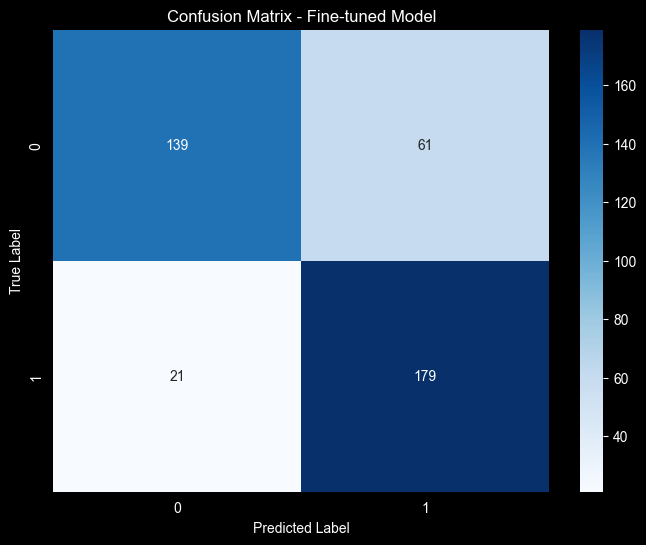

=== Fine-tuned Model ===
              precision    recall  f1-score   support

           0       0.87      0.69      0.77       200
           1       0.75      0.90      0.81       200

    accuracy                           0.80       400
   macro avg       0.81      0.79      0.79       400
weighted avg       0.81      0.80      0.79       400


=== Baseline Model ===
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       200
           1       0.75      0.78      0.77       200

    accuracy                           0.76       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.76      0.76      0.76       400


=== Сравнение ===
Fine-tuned F1: 0.7929, Accuracy: 0.7950
Baseline F1: 0.7624, Accuracy: 0.7625
Улучшение F1: 4.00%


In [1]:
from sklearn.metrics import confusion_matrix
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib
import numpy as np

model_ft = AutoModelForSequenceClassification.from_pretrained('./fine_tuned_model')
tokenizer = AutoTokenizer.from_pretrained('./fine_tuned_model')
model_ft.eval()

baseline_model = joblib.load('baseline_model.pkl')
baseline_scaler = joblib.load('baseline_vectorizer.pkl')

baseline_model_name = "bert-base-uncased"
baseline_tokenizer = AutoTokenizer.from_pretrained(baseline_model_name)
baseline_bert = AutoModel.from_pretrained(baseline_model_name)
baseline_bert.eval()

import pandas as pd
from sklearn.model_selection import train_test_split

if 'val_texts' not in globals() or 'val_labels' not in globals():
    df = pd.read_csv('data/imdb_small.csv')
    texts = df['text'].tolist()
    labels = df['label'].tolist()
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        texts, labels, test_size=0.2, random_state=42, stratify=labels
    )
    print(f'Loaded {len(val_texts)} validation samples')

def predict_fine_tuned(texts, model, tokenizer):
    if isinstance(texts, str):
        texts = [texts]

    predictions = []

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

        predictions.append({
        'text': text,
        'prediction': pred,
        'probabilities': probs[0].cpu().numpy()
        })

    return predictions

def predict_baseline(texts, model, scaler, bert_model, bert_tokenizer, batch_size=32):
    if isinstance(texts, str):
        texts = [texts]

    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        batch_tokens = bert_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = bert_model(**batch_tokens)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())

    X = np.vstack(all_embeddings)
    X_scaled = scaler.transform(X)
    predictions = model.predict(X_scaled)
    probs = model.predict_proba(X_scaled) if hasattr(model, 'predict_proba') else None

    results = []
    for i, text in enumerate(texts):
        results.append({
              'text': text,
        'prediction': int(predictions[i]),
        'probabilities': probs[i] if probs is not None else None
        })

    return results

test_texts = [
    "This movie was absolutely fantastic!",
    "Terrible, waste of my time.",
    "It was okay, nothing special.",
    "Best film I've seen this year!",
    "Boring and too long."
]

# Fine-tuned predictions
preds_ft = predict_fine_tuned(test_texts, model_ft, tokenizer)

# Baseline predictions (если есть)
if baseline_model is not None:
    preds_baseline = predict_baseline(test_texts, baseline_model, baseline_scaler, baseline_bert, baseline_tokenizer)

for i, text in enumerate(test_texts):
    print(f'\nТекст: {text}')
    print(f'Fine-tuned: {preds_ft[i]["prediction"]} (probs: {preds_ft[i]["probabilities"]})')
    if baseline_model:
        print(f'Baseline: {preds_baseline[i]["prediction"]}')
        print(f'Совпадают: {preds_ft[i]["prediction"] == preds_baseline[i]["prediction"]}')


test_texts = val_texts
test_labels = val_labels

preds_ft_all = predict_fine_tuned(test_texts, model_ft, tokenizer)
y_pred_ft = [p['prediction'] for p in preds_ft_all]

cm_ft = confusion_matrix(test_labels, y_pred_ft)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Fine-tuned Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_finetuned.png')
plt.show()

# ЗАДАЧА 6: Сравнение метрик
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Fine-tuned
print("=== Fine-tuned Model ===")
print(classification_report(test_labels, y_pred_ft))
f1_ft = f1_score(test_labels, y_pred_ft, average='macro')
acc_ft = accuracy_score(test_labels, y_pred_ft)

# Baseline (если есть)
if baseline_model:
    preds_baseline_all = predict_baseline(test_texts, baseline_model, baseline_scaler, baseline_bert, baseline_tokenizer)
    y_pred_base = [p['prediction'] for p in preds_baseline_all]

    print("\n=== Baseline Model ===")
    print(classification_report(test_labels, y_pred_base))
    f1_base = f1_score(test_labels, y_pred_base, average='macro')
    acc_base = accuracy_score(test_labels, y_pred_base)

    print(f'\n=== Сравнение ===')
    print(f'Fine-tuned F1: {f1_ft:.4f}, Accuracy: {acc_ft:.4f}')
    print(f'Baseline F1: {f1_base:.4f}, Accuracy: {acc_base:.4f}')
    print(f'Улучшение F1: {(f1_ft - f1_base) / f1_base * 100:.2f}%')

# ЗАДАЧА 7: Сохранение результатов сравнения
with open('comparison_results.txt', 'w') as f:
    f.write('=== Сравнение моделей ===\n\n')
    f.write(f'Fine-tuned Model:\n')
    f.write(f'  F1 (macro): {f1_ft:.4f}\n')
    f.write(f'  Accuracy: {acc_ft:.4f}\n')

    if baseline_model:
        f.write(f'\nBaseline Model:\n')
        f.write(f'  F1 (macro): {f1_base:.4f}\n')
        f.write(f'  Accuracy: {acc_base:.4f}\n')
        f.write(f'\nУлучшение: {(f1_ft - f1_base) / f1_base * 100:.2f}%\n')


In [5]:
import pandas as pd

# ЗАДАЧА 1: Анализ False Positive и False Negative
df_test = pd.DataFrame({
    'text': test_texts,
    'true_label': test_labels,
    'pred_label': y_pred_ft
})

errors = df_test[df_test['true_label'] != df_test['pred_label']].copy()

fp = errors[(errors['pred_label'] == 1) & (errors['true_label'] == 0)]
fn = errors[(errors['pred_label'] == 0) & (errors['true_label'] == 1)]

print(f'Всего ошибок: {len(errors)}')
print(f'False Positives: {len(fp)}')
print(f'False Negatives: {len(fn)}')

# ЗАДАЧА 2: Анализ паттернов ошибок
print("\n=== FALSE POSITIVES (сказали good, а было bad) ===")
for idx, row in fp.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')

print("\n=== FALSE NEGATIVES (сказали bad, а было good) ===")
for idx, row in fn.head(5).iterrows():
    print(f'\nТекст: {row["text"][:100]}...')
    print(f'Истинный класс: {row["true_label"]}, Предсказан: {row["pred_label"]}')

errors['text_length'] = errors['text'].str.len()
print(f'\nСредняя длина ошибочных текстов: {errors["text_length"].mean():.0f}')
print(f'Средняя длина всех текстов: {df_test["text"].str.len().mean():.0f}')

with open('error_analysis.txt', 'w') as f:
    f.write('=== АНАЛИЗ ОШИБОК ===\n\n')
    f.write(f'Всего ошибок: {len(errors)}\n')
    f.write(f'False Positives: {len(fp)}\n')
    f.write(f'False Negatives: {len(fn)}\n\n')

    f.write('=== ПРИМЕРЫ FALSE POSITIVES ===\n')
    for idx, row in fp.head(5).iterrows():
        f.write(f'\nТекст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')

    f.write('\n\n=== ПРИМЕРЫ FALSE NEGATIVES ===\n')
    for idx, row in fn.head(5).iterrows():
        f.write(f'Текст: {row["text"]}\n')
        f.write(f'Истинный: {row["true_label"]}, Предсказан: {row["pred_label"]}\n')

    f.write('\n\n=== НАБЛЮДЕНИЯ ===\n')
    f.write('1. Сарказм и ирония: FP-примеры содержат позитивные слова в негативном контексте ("As good an advert", "Great wasted night stuff"). Модель не распознаёт сарказм.\n')
    f.write('2. Смешанные отзывы: многие ошибки содержат и позитивные, и негативные элементы. Модель цепляется за позитивные слова и игнорирует общий тон.\n')
    f.write('3. Длина текста: ошибочные тексты в среднем длиннее (1646 vs 1332 символов). Длинные развёрнутые отзывы сложнее классифицировать.\n')
    f.write('4. FP доминируют (61 vs 21): модель смещена в сторону positive. Recall для negative = 0.69, что подтверждает системный bias.\n')
    f.write('5. FN-паттерн: положительные отзывы с критикой отдельных аспектов ("Downside:...", "the rest is crap") сбивают модель.\n')
    f.write('6. Аналитические обзоры: развёрнутые обзоры с техническим анализом (как обзор Burton) путают модель — она реагирует на отдельные слова, а не на общую оценку.\n')
    f.write('7. Рекомендации: увеличить датасет, добавить class weights для балансировки, попробовать больший max_length для длинных текстов.\n')


Всего ошибок: 82
False Positives: 61
False Negatives: 21

=== FALSE POSITIVES (сказали good, а было bad) ===

Текст: As good an advert for republicanism as you're ever likely to see,"Mayerling"is an everyday story of ...
Истинный класс: 0, Предсказан: 1

Текст: The first 30min of the flick was choppy and hard to know just what was going on (unless you read the...
Истинный класс: 0, Предсказан: 1

Текст: What a shame that Alan Clarke has to be associated with this tripe. That doesn't rule it out however...
Истинный класс: 0, Предсказан: 1

Текст: OK we all love the daisy dukes, but what is up with this cast. Lets start, Jessica Simpson as Daisy,...
Истинный класс: 0, Предсказан: 1

Текст: This film is another of director Tim Burton's attempts to capitalize on a familiar title to bring hi...
Истинный класс: 0, Предсказан: 1

=== FALSE NEGATIVES (сказали bad, а было good) ===

Текст: I'm grateful to Cesar Montano and his crew in reviving the once-moribund Visayan film understorey. "...
Ис